In [ ]:
import pandas as pd

data = {
    "Month": [
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12",
        "2026-01", "2026-02", "2026-03", "2026-04",
        "2026-05", "2026-06", "2026-07", "2026-08"
    ],
    "Revenue": [
        120000, 125000, 132000, 128000,
        140000, 145000, 150000, 148000,
        155000, 162000, 170000, 178000,
        175000, 182000, 190000, 195000,
        202000, 210000, 218000, 225000
    ]
}

df = pd.DataFrame(data)

df.head()

,Month,Revenue
0,2025-01,120000
1,2025-02,125000
2,2025-03,132000
3,2025-04,128000
4,2025-05,140000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Month    20 non-null     object
 1   Revenue  20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


In [ ]:
df.isnull().sum()

In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

df.head()

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
data = {
    "Month": [
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12",
        "2026-01", "2026-02", "2026-03", "2026-04",
        "2026-05", "2026-06", "2026-07", "2026-08"
    ],
    "Revenue": [
        120000, 125000, 132000, 128000,
        140000, 145000, 150000, 148000,
        155000, 162000, 170000, 178000,
        175000, 182000, 190000, 195000,
        202000, 210000, 218000, 225000
    ]
}

df = pd.DataFrame(data)

df.head()

,Month,Revenue
0,2025-01,120000
1,2025-02,125000
2,2025-03,132000
3,2025-04,128000
4,2025-05,140000


In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

df.head()

,Month,Revenue
0,2025-01-01,120000
1,2025-02-01,125000
2,2025-03-01,132000
3,2025-04-01,128000
4,2025-05-01,140000


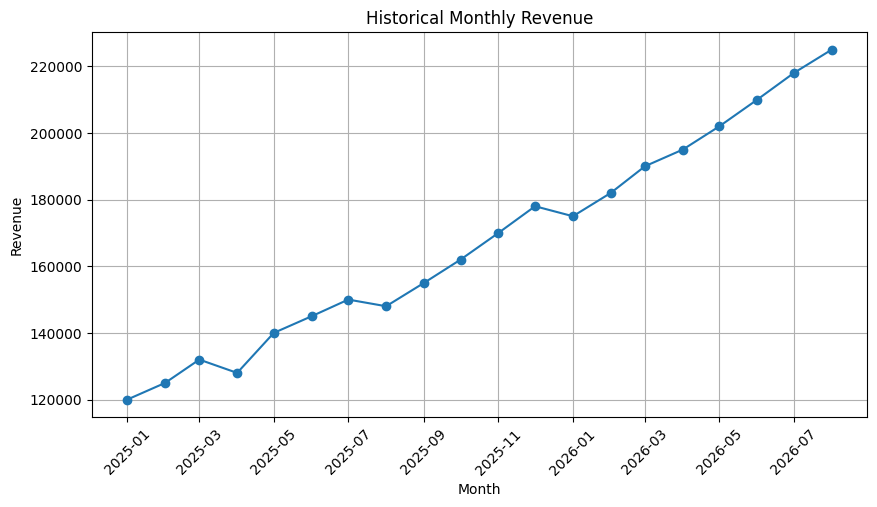

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["Revenue"], marker="o")
plt.title("Historical Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
df["Month_Number"] = range(1, len(df) + 1)

df.head()

,Month,Revenue,Month_Number
0,2025-01-01,120000,1
1,2025-02-01,125000,2
2,2025-03-01,132000,3
3,2025-04-01,128000,4
4,2025-05-01,140000,5


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Month_Number"]]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 16
Testing records: 4


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual Revenue:")
print(y_test.values)

print("\nPredicted Revenue:")
print(y_pred)

Actual Revenue:
[202000 210000 218000 225000]

Predicted Revenue:
[198150.         203116.17647059 208082.35294118 213048.52941176]


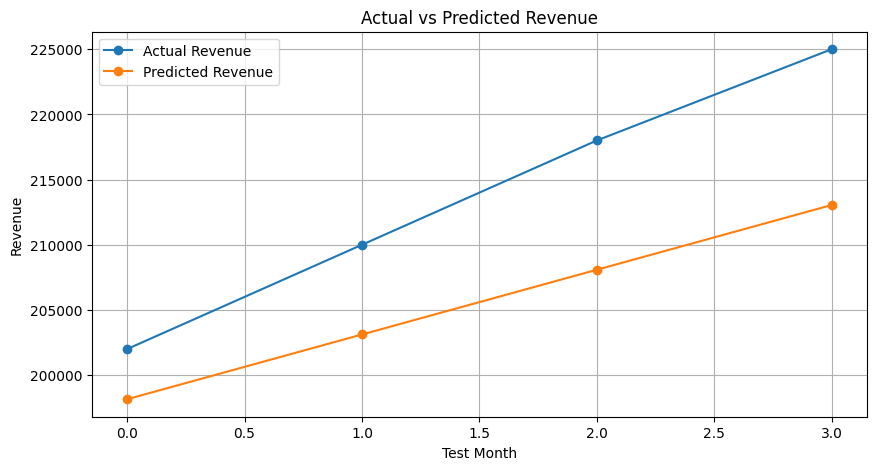

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker="o", label="Actual Revenue")
plt.plot(y_pred, marker="o", label="Predicted Revenue")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Test Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
future_months = pd.DataFrame({
    "Month_Number": range(21, 27)
})

future_predictions = model.predict(future_months)

future_dates = pd.date_range(
    start="2026-09-01",
    periods=6,
    freq="MS"
)

future_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted_Revenue": future_predictions
})

future_df

,Month,Predicted_Revenue
0,2026-09-01,218014.705882
1,2026-10-01,222980.882353
2,2026-11-01,227947.058824
3,2026-12-01,232913.235294
4,2027-01-01,237879.411765
5,2027-02-01,242845.588235


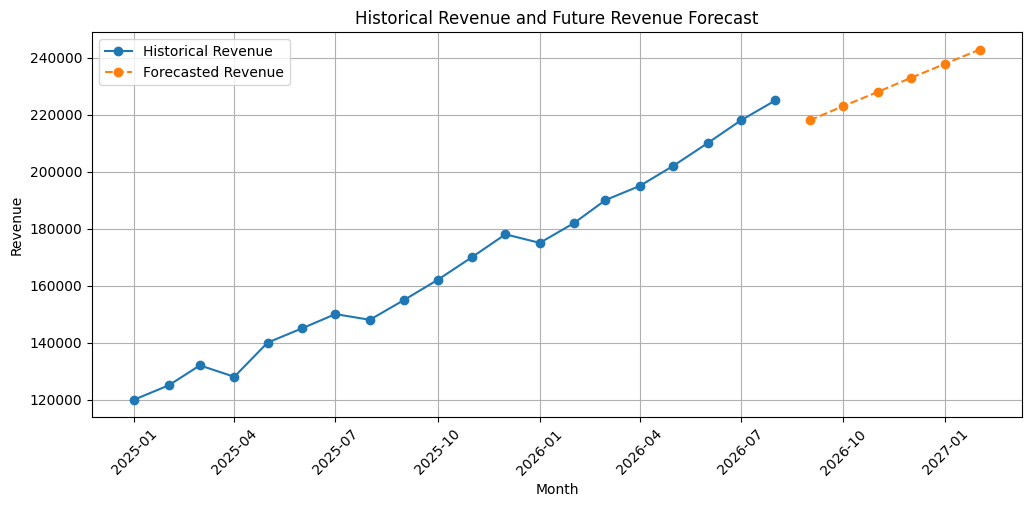

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Month"],
    df["Revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    future_df["Month"],
    future_df["Predicted_Revenue"],
    marker="o",
    linestyle="--",
    label="Forecasted Revenue"
)

plt.title("Historical Revenue and Future Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
future_df.to_csv("future_revenue_forecast.csv", index=False)

print("Forecast saved successfully!")

Forecast saved successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 8150.74
Root Mean Squared Error (RMSE): 8709.29
R² Score: -0.0224


In [ ]:
performance = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [mae, rmse, r2]
})

performance["Value"] = performance["Value"].round(2)

performance

,Metric,Value
0,MAE,8150.74
1,RMSE,8709.29
2,R2 Score,-0.02


In [ ]:
final_forecast = future_df.copy()

final_forecast["Predicted_Revenue"] = (
    final_forecast["Predicted_Revenue"].round(2)
)

final_forecast

,Month,Predicted_Revenue
0,2026-09-01,218014.71
1,2026-10-01,222980.88
2,2026-11-01,227947.06
3,2026-12-01,232913.24
4,2027-01-01,237879.41
5,2027-02-01,242845.59


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Historical dataset
data = {
    "Month": [
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12",
        "2026-01", "2026-02", "2026-03", "2026-04",
        "2026-05", "2026-06", "2026-07", "2026-08"
    ],
    "Revenue": [
        120000, 125000, 132000, 128000,
        140000, 145000, 150000, 148000,
        155000, 162000, 170000, 178000,
        175000, 182000, 190000, 195000,
        202000, 210000, 218000, 225000
    ]
}

df = pd.DataFrame(data)

# Convert Month to date
df["Month"] = pd.to_datetime(df["Month"])

# Create month number
df["Month_Number"] = range(1, len(df) + 1)

# Prepare data
X = df[["Month_Number"]]
y = df["Revenue"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model restored successfully!")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model restored successfully!
MAE: 8150.74
RMSE: 8709.29
R² Score: -0.0224


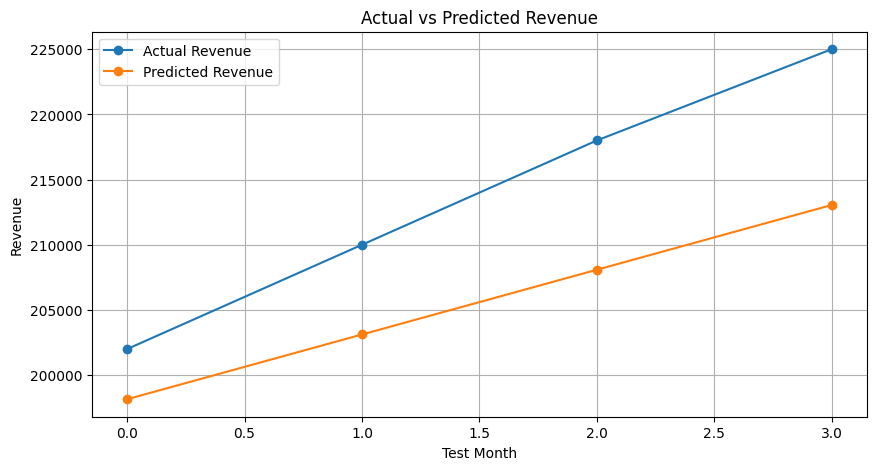

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker="o", label="Actual Revenue")
plt.plot(y_pred, marker="o", label="Predicted Revenue")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Test Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
future_months = pd.DataFrame({
    "Month_Number": range(21, 27)
})

future_predictions = model.predict(future_months)

future_dates = pd.date_range(
    start="2026-09-01",
    periods=6,
    freq="MS"
)

future_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted_Revenue": future_predictions
})

future_df["Predicted_Revenue"] = future_df["Predicted_Revenue"].round(2)

future_df

,Month,Predicted_Revenue
0,2026-09-01,218014.71
1,2026-10-01,222980.88
2,2026-11-01,227947.06
3,2026-12-01,232913.24
4,2027-01-01,237879.41
5,2027-02-01,242845.59


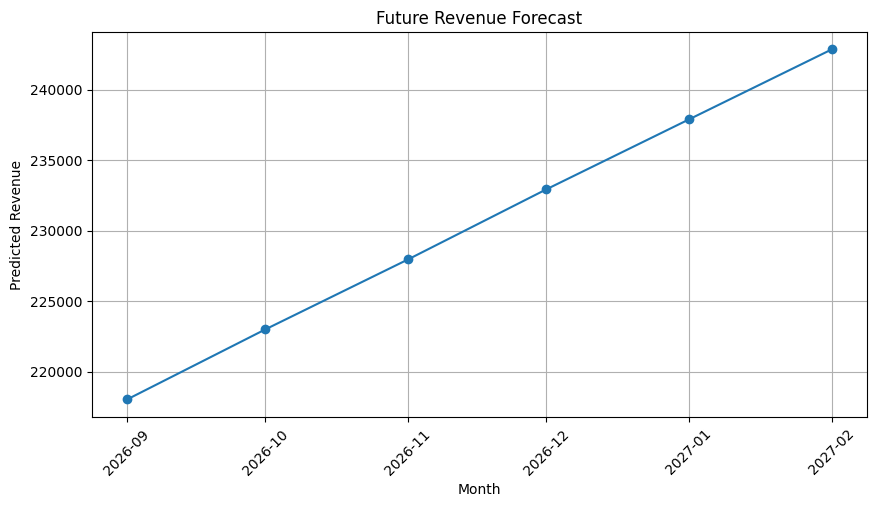

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    future_df["Month"],
    future_df["Predicted_Revenue"],
    marker="o"
)

plt.title("Future Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()